In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
Path to dataset files: /kaggle/input/students-performance-in-exams


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import pickle

In [14]:
df = pd.read_csv('StudentsPerformance.csv')

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [15]:
print("Jumlah Data dan Kolom:")
print(df.shape)

print("\nInformasi Dataset:")
print(df.info())

print("\nMissing Value:")
print(df.isnull().sum())

print("\nStatistik Deskriptif:")
print(df.describe())

Jumlah Data dan Kolom:
(1000, 8)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

Missing Value:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
re

In [16]:
df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

df['status_kelulusan'] = np.where(
    df['average_score'] >= 75,
    1,
    0
)

df[['average_score','status_kelulusan']].head()

,average_score,status_kelulusan
0,72.666667,0
1,82.333333,1
2,92.666667,1
3,49.333333,0
4,76.333333,1


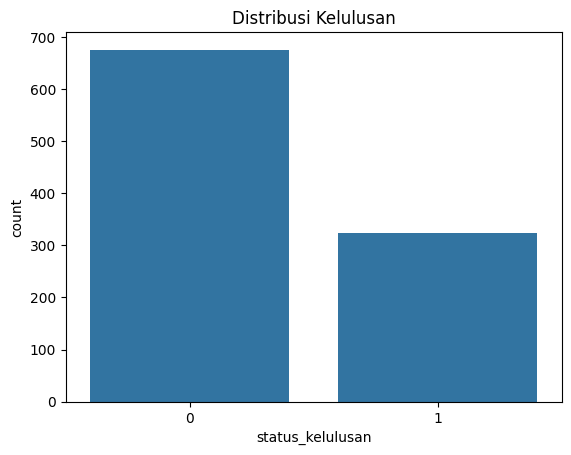

In [17]:
sns.countplot(
    x='status_kelulusan',
    data=df
)

plt.title('Distribusi Kelulusan')
plt.show()

In [18]:
le = LabelEncoder()

categorical_columns = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,status_kelulusan
0,0,1,1,1,1,72,72,74,72.666667,0
1,0,2,4,1,0,69,90,88,82.333333,1
2,0,1,3,1,1,90,95,93,92.666667,1
3,1,0,0,0,1,47,57,44,49.333333,0
4,1,2,4,1,1,76,78,75,76.333333,1


In [19]:
X = df.drop(
    ['status_kelulusan', 'average_score'],
    axis=1
)

y = df['status_kelulusan']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800, 8)
(200, 8)


In [21]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [27]:
y_pred = rf.predict(X_test)

In [28]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred
))

Accuracy : 0.98

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       136
           1       0.97      0.97      0.97        64

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



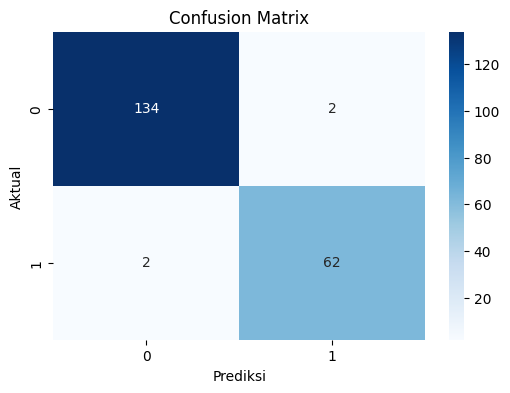

In [29]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

plt.show()

                       Feature  Importance
5                   math score    0.328451
6                reading score    0.320888
7                writing score    0.283697
0                       gender    0.015850
2  parental level of education    0.014504
1               race/ethnicity    0.014007
4      test preparation course    0.011922
3                        lunch    0.010681


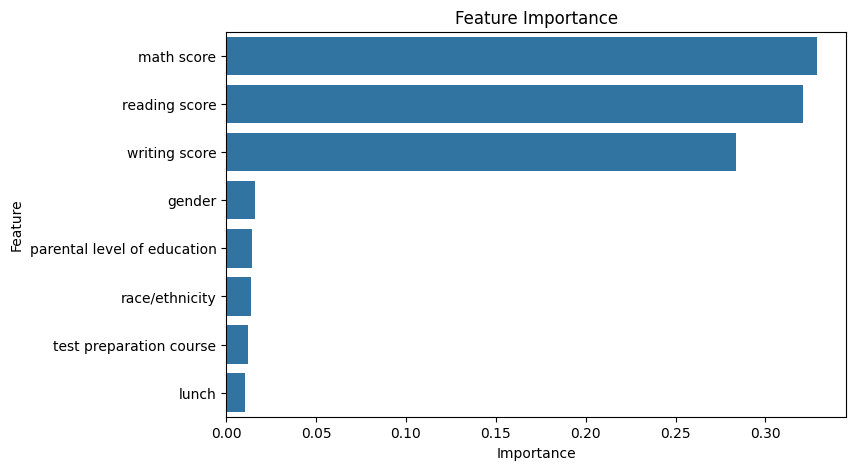

In [24]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')
plt.show()

In [23]:
pickle.dump(
    rf,
    open('model_kelulusan.pkl','wb')
)

print("Model berhasil disimpan")

Model berhasil disimpan


In [22]:
data_baru = [[
    0,  # gender
    2,  # race
    3,  # education
    1,  # lunch
    1,  # preparation
    80, # math
    85, # reading
    90  # writing
]]

hasil = rf.predict(data_baru)

if hasil[0] == 1:
    print("LULUS")
else:
    print("TIDAK LULUS")

LULUS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
